In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis as k
print('====== IMPORT COMPLETED ======')

====== IMPORT COMPLETED ======


In [3]:
df = pd.read_csv('AGRI DATASET.csv')

In [4]:
col_name = 'RICE YIELD (Kg per ha)'
data = df[col_name].dropna()  

'''dropna() removes missing, null, or NaN (Not a Number) values from your dataset.'''

'dropna() removes missing, null, or NaN (Not a Number) values from your dataset.'

In [5]:
''' HERE THE FISHER MAN'S FORMULA IS USED ...'''
kurt_f = k(data, fisher=True)

In [6]:
''' here KARL PEARSON FORMULA IS USED ...'''
kurt_w = k(data, fisher=False)

In [7]:
print(f"--- Kurtosis Analysis for {col_name} ---")
print("Fisher Kurtosis:", kurt_f)
print("Pearson Kurtosis:", kurt_w)

--- Kurtosis Analysis for RICE YIELD (Kg per ha) ---
Fisher Kurtosis: 0.14886482169953386
Pearson Kurtosis: 3.148864821699534


In [8]:
mean_val = np.mean(data)
min_val = np.min(data)
max_val = np.max(data)

In [9]:
if kurt_f > 0:   
    ''' condition for the three kind of kurtosis : lepto , meso , platy ( flat , correct , low ) noise values '''
    print("Leptokurtic (Heavy tail - presence of extreme outliers)")
    if (max_val - mean_val) > (mean_val - min_val):  
        ''' tO VALIDATE PROFIT THIS FORMULA IS CORRECT HERE '''
        print("Tail spreads more towards higher yields")
    else:
        print("Tail spreads more towards lower yields")
elif kurt_f < 0:
    print("Platykurtic (Flat distribution - uniform variation)")
else:
    print("Mesokurtic (Normal distribution)")

Leptokurtic (Heavy tail - presence of extreme outliers)
Tail spreads more towards higher yields


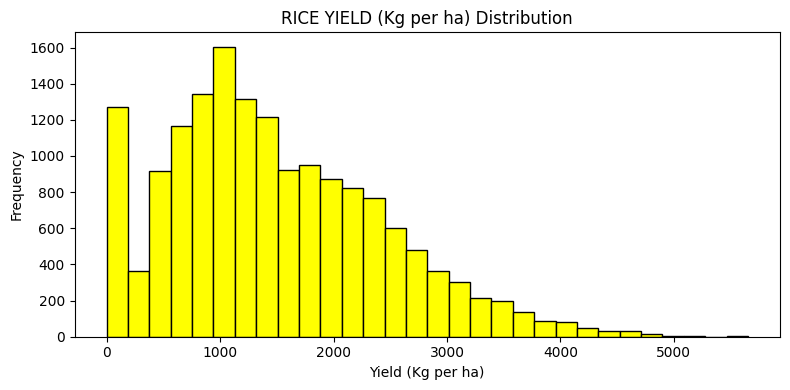

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(data, bins=30, color="yellow", edgecolor="black")
plt.xlabel("Yield (Kg per ha)")
plt.ylabel("Frequency")
plt.title(f"{col_name} Distribution")
plt.tight_layout()
plt.show()

Mean yield: 1486.9247838473925
Median yield: 1333.21


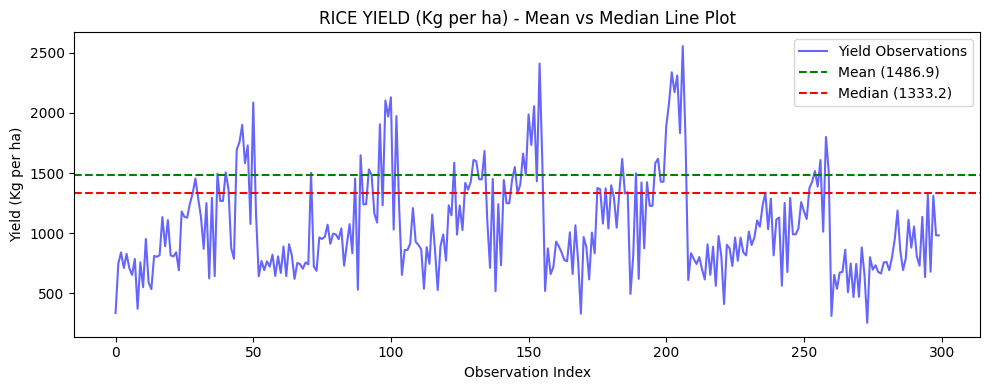

In [11]:
median_val = np.median(data)

print("Mean yield:", mean_val)
print("Median yield:", median_val)

plt.figure(figsize=(10, 4))
plt.plot(data.values[:300], color="blue", alpha=0.6, label="Yield Observations")
plt.axhline(mean_val, linestyle="--", color="green", label=f"Mean ({mean_val:.1f})", linewidth=1.5)
plt.axhline(median_val, linestyle="--", color="red", label=f"Median ({median_val:.1f})", linewidth=1.5)
plt.xlabel("Observation Index")
plt.ylabel("Yield (Kg per ha)")
plt.title(f"{col_name} - Mean vs Median Line Plot")
plt.legend()
plt.tight_layout()
plt.show()

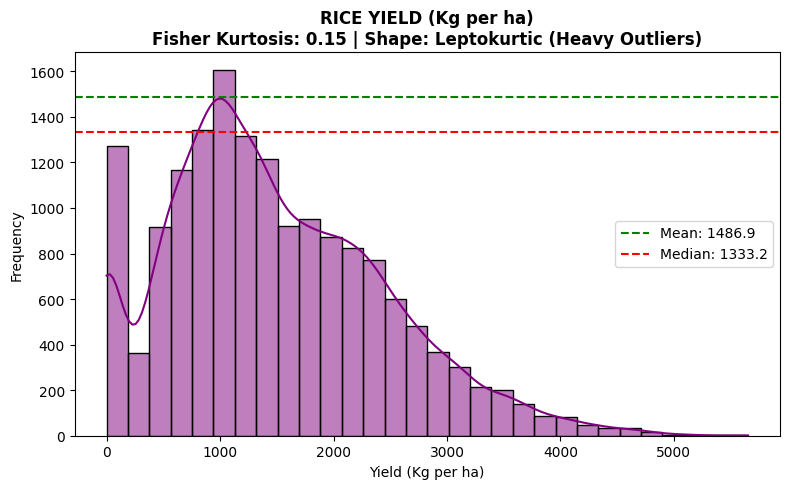

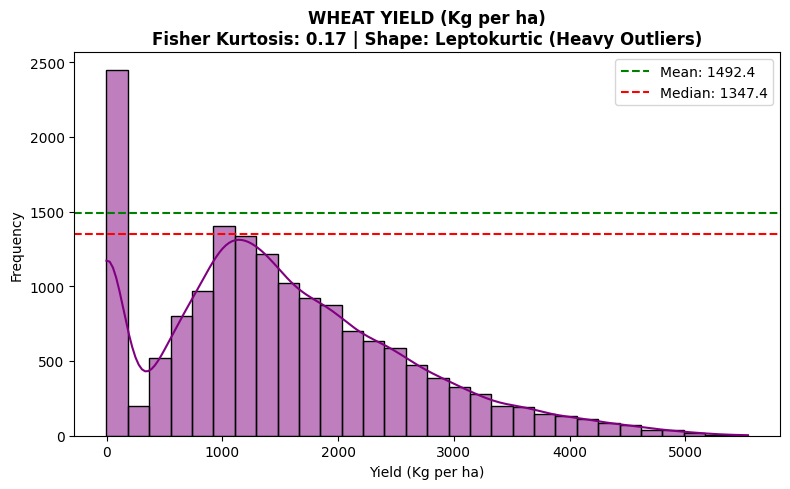

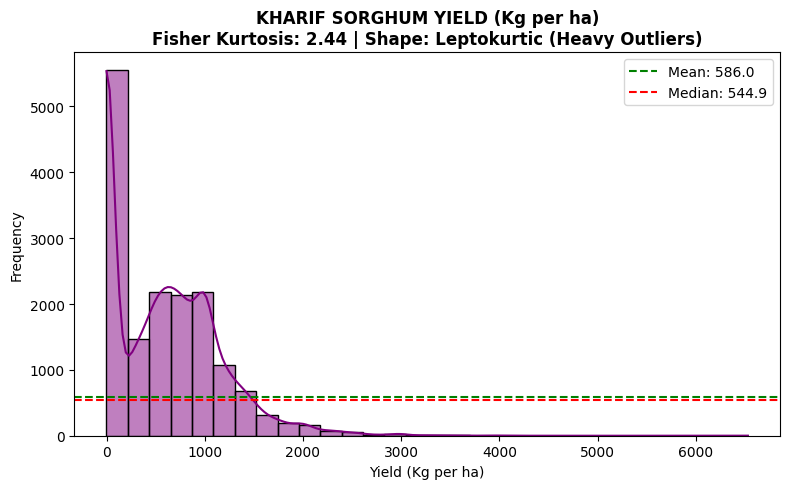

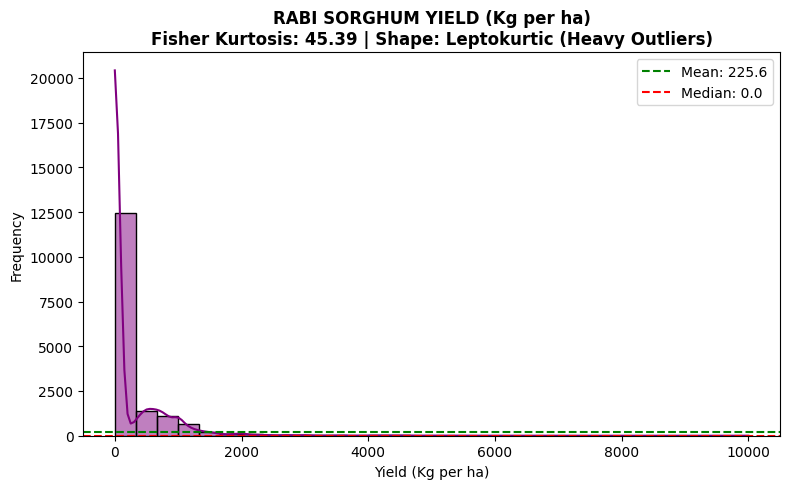

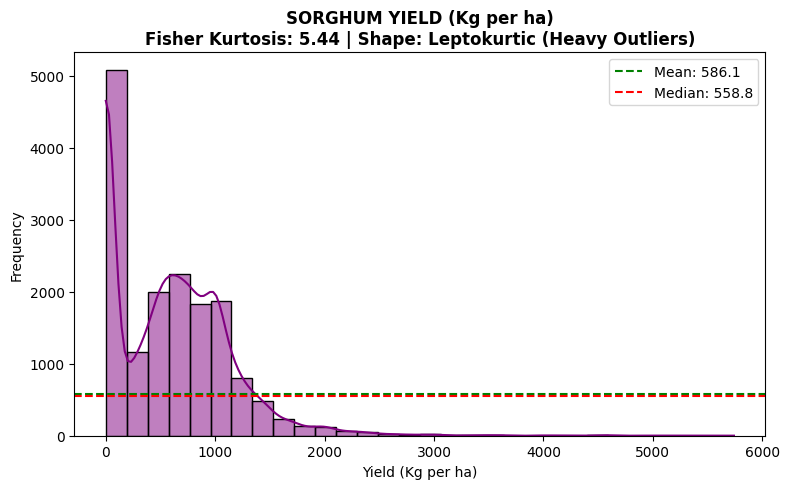

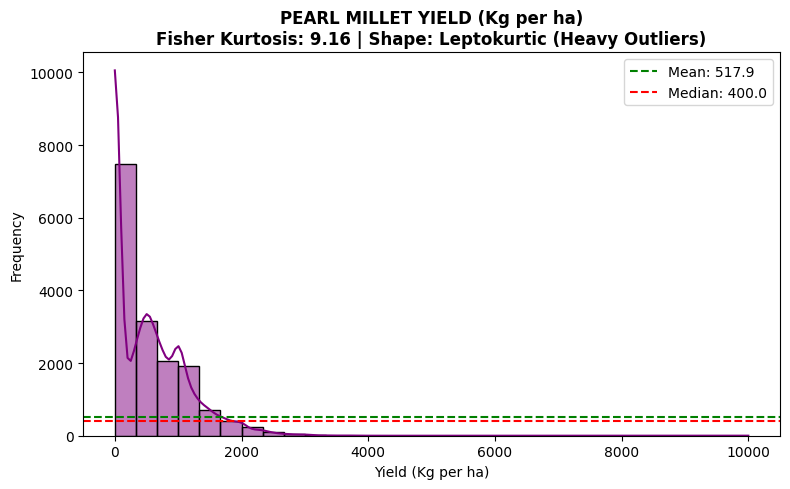

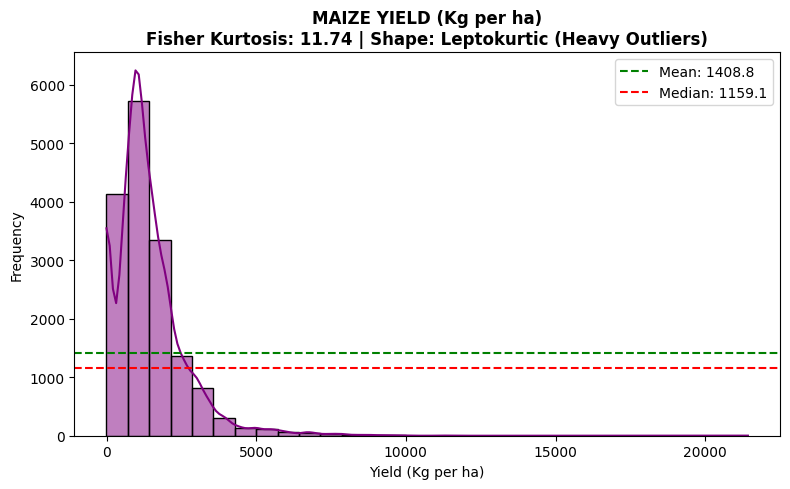

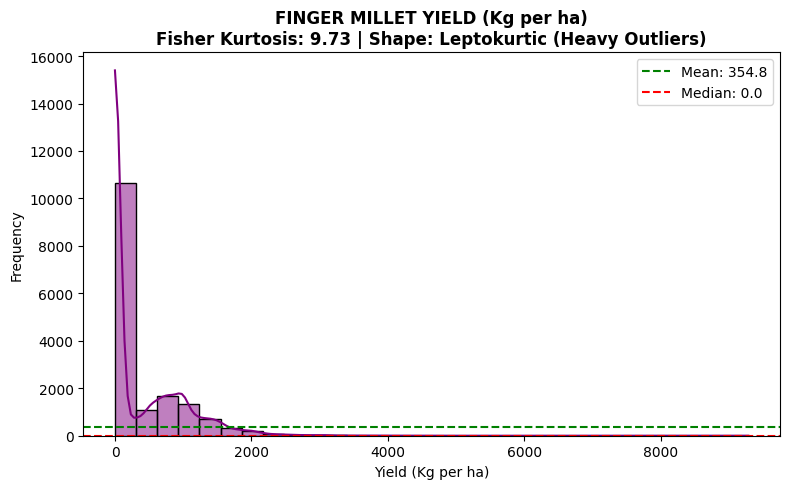

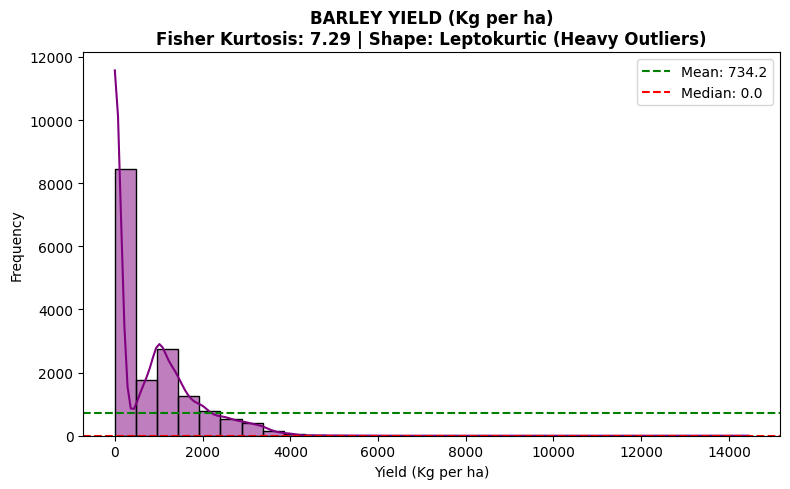

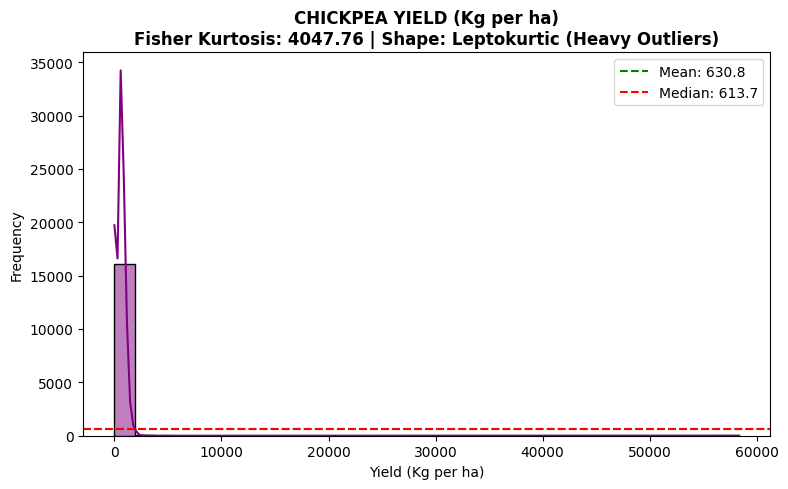

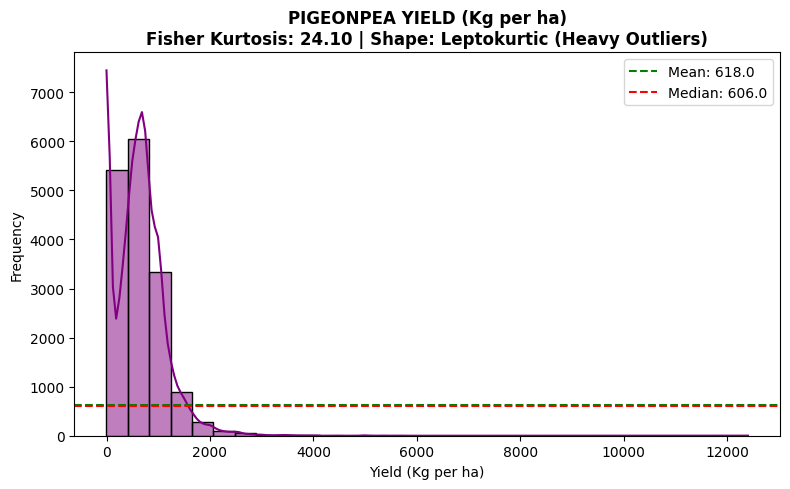

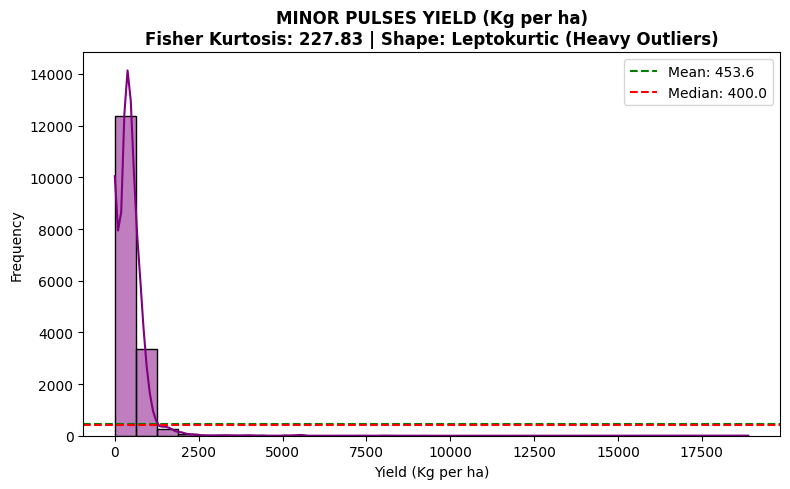

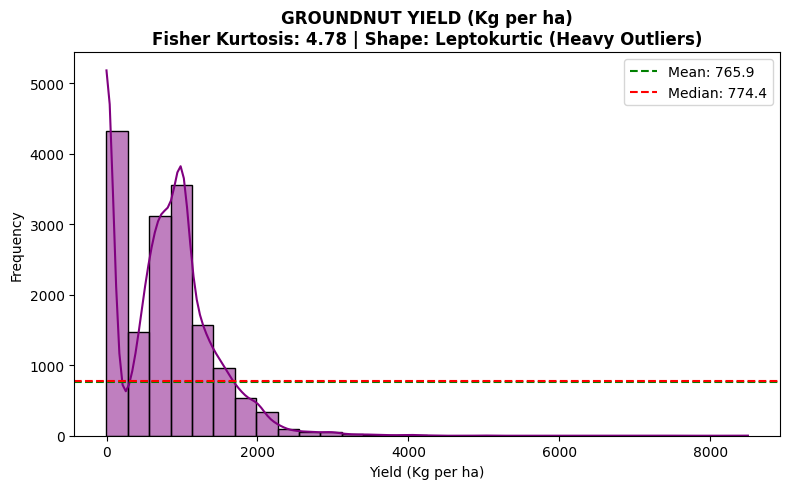

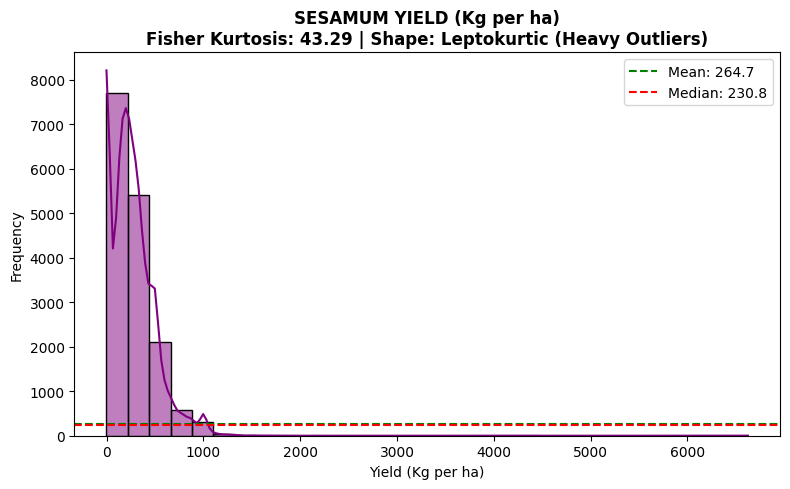

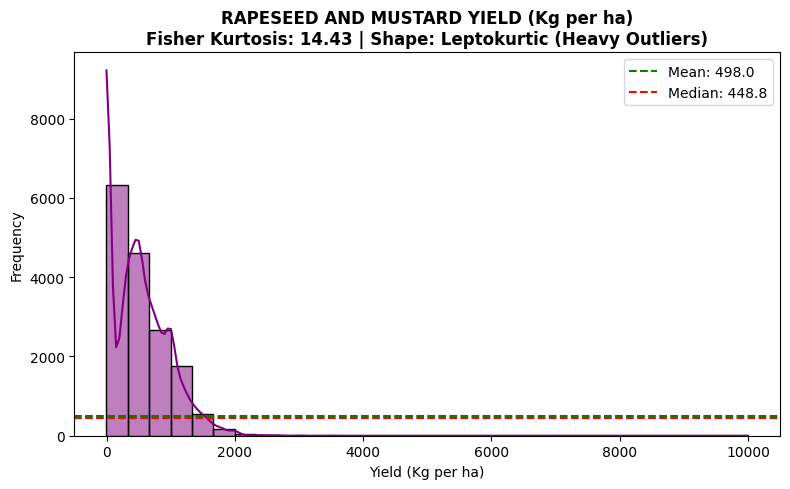

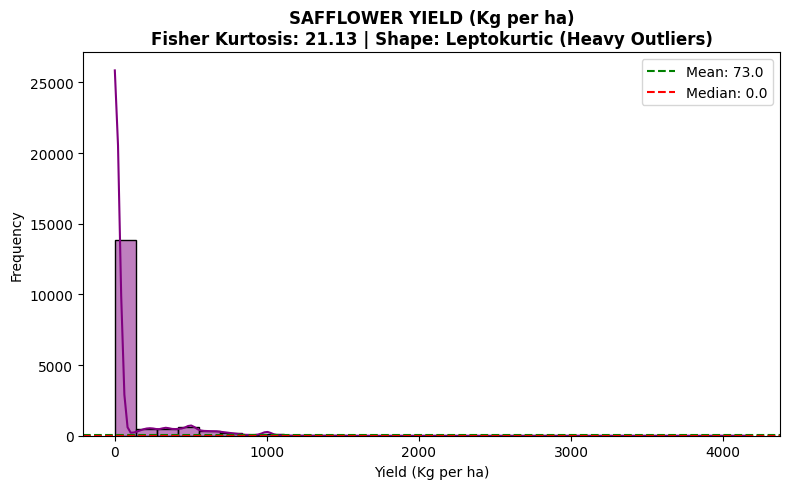

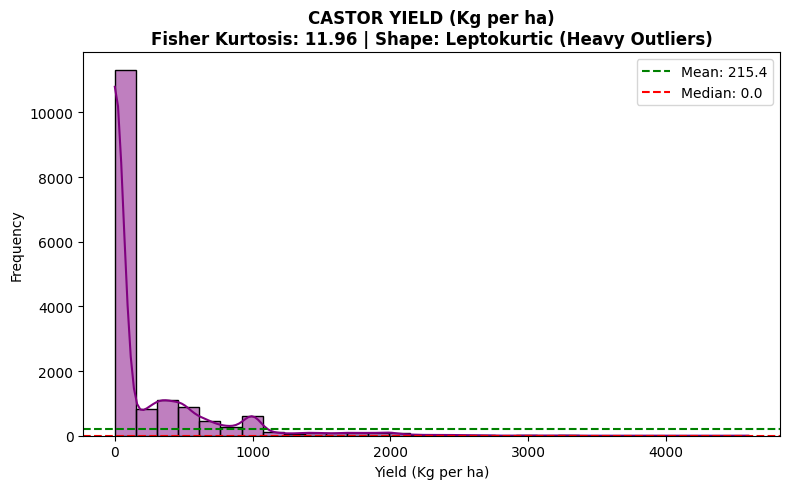

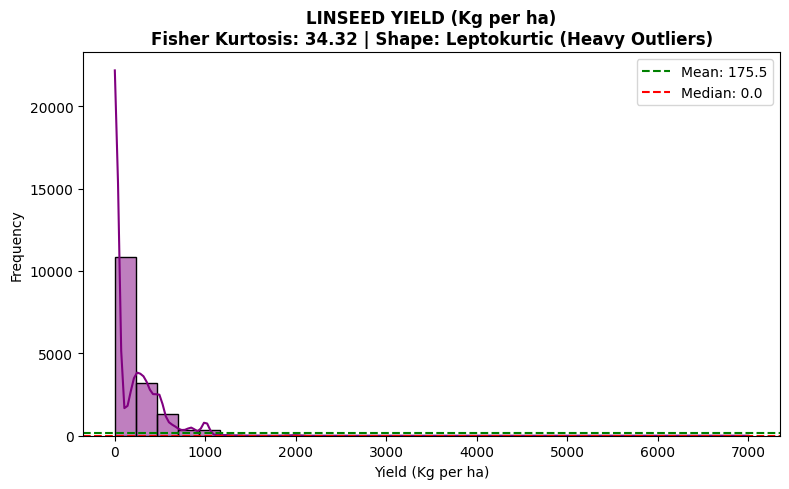

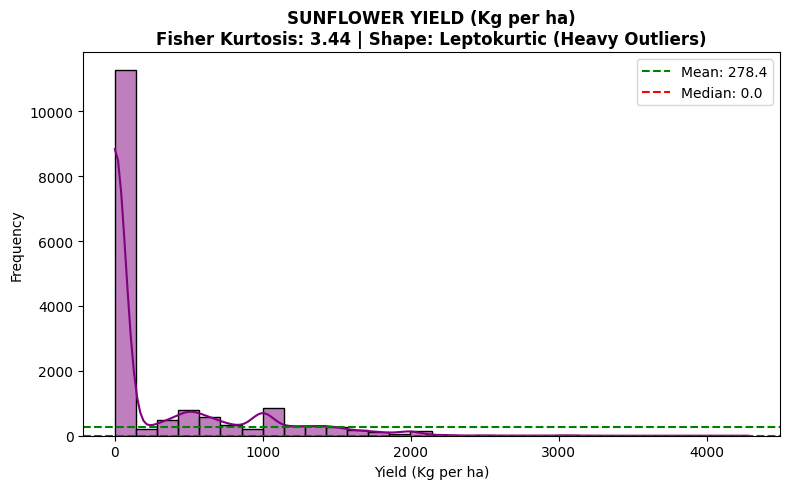

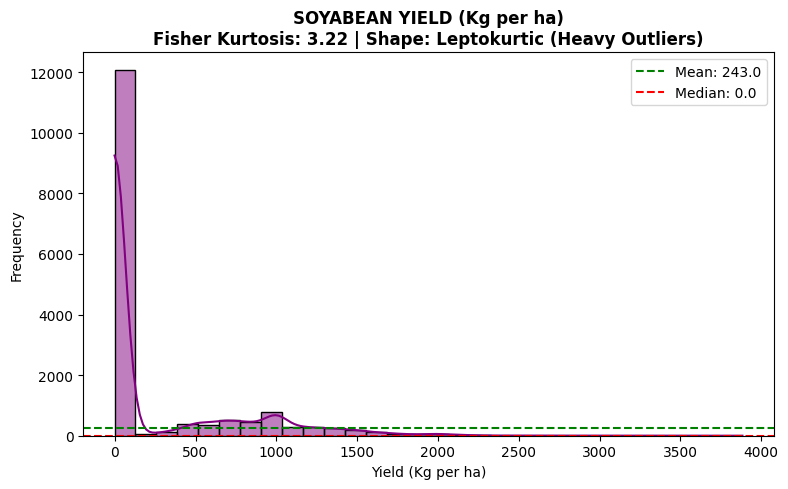

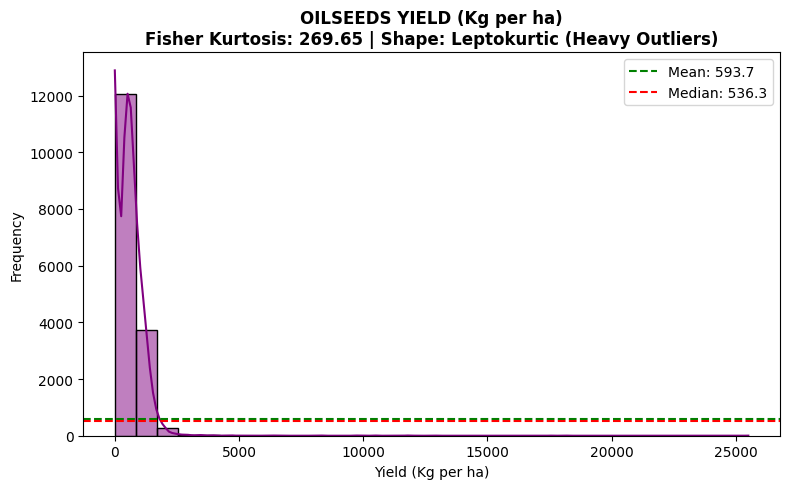

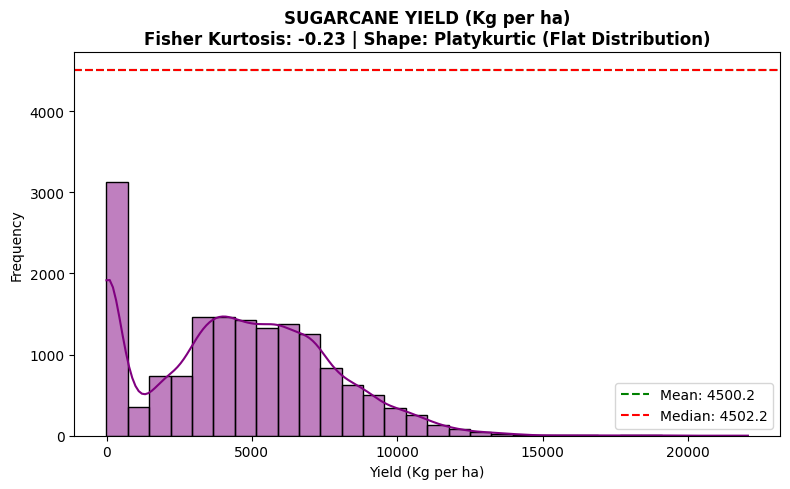

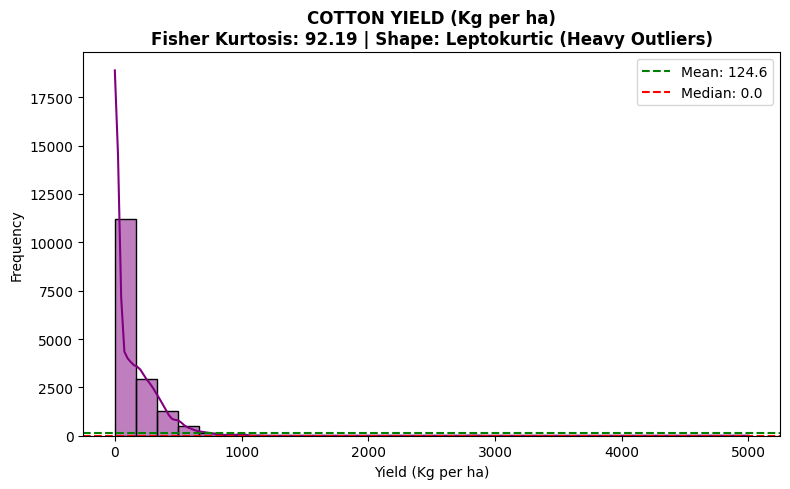

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kurtosis as k

yield_cols = [col for col in df.columns if 'YIELD' in col]

for col in yield_cols:
    val = df[col].dropna()
    k_val = k(val, fisher=True)
    
    if k_val > 0:
        shape = "Leptokurtic (Heavy Outliers)"
    elif k_val < 0:
        shape = "Platykurtic (Flat Distribution)"
    else:
        shape = "Mesokurtic (Near Normal)"
        
    plt.figure(figsize=(8, 5))
    
    # Histogram with Kernel Density Estimate (KDE) curve
    sns.histplot(val, kde=True, color='purple', bins=30)
    
    # Annotate mean and median lines
    plt.axhline(val.mean(), color='green', linestyle='--', label=f'Mean: {val.mean():.1f}')
    plt.axhline(val.median(), color='red', linestyle='--', label=f'Median: {val.median():.1f}')
    
    plt.title(f"{col}\nFisher Kurtosis: {k_val:.2f} | Shape: {shape}", fontsize=12, fontweight='bold')
    plt.xlabel("Yield (Kg per ha)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()